# F1 Race Strategy - Data Exploration & Analysis
This notebook contains the exploratory analysis of the cleaned Formula 1 circuits and race results datasets. We explore the impacts of weather conditions, tyre compound selection, pit stop strategies, and track characteristics on overall race performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Cleaned Datasets
We load `f1_circuits_cleaned.csv` and `f1_race_results_cleaned.csv` which were generated in the data cleaning phase.

In [2]:
circuits_df = pd.read_csv('f1_circuits_cleaned.csv')
results_df = pd.read_csv('f1_race_results_cleaned.csv')

print(f"Circuits dataset shape: {circuits_df.shape}")
print(f"Results dataset shape: {results_df.shape}")

Circuits dataset shape: (700, 31)
Results dataset shape: (700, 36)


## 2. Merge Data
We join the race results with sirkuit layouts on `circuit_id` to enable unified analysis.

In [3]:
df = pd.merge(results_df, circuits_df, on='circuit_id')
df.head()

,result_id,season,round_number,circuit_id,driver_id,driver_name,driver_nationality,team_name,grid_position,qualifying_position,...,ticket_price_usd,safety_car_freq,overtake_index,night_race,primary_engine_supplier,primary_broadcast_lang,pit_boxes,marshal_post_count,total_race_dist_km,elevation_change_m
0,16447953,2018,2,25561463,30040704,Logan Sargeant,USA,Williams,2,19,...,1122,0.248,3.89,0,Mercedes,IT,17,26,343.07,137
1,12456772,2023,1,26518841,33240186,Charles Leclerc,MON,Ferrari,3,19,...,2274,0.566,6.23,1,Honda,ZH,22,26,292.25,109
2,18212789,2022,20,21462677,30040704,Logan Sargeant,USA,Williams,20,4,...,2898,0.381,1.47,1,Ferrari,ZH,16,24,166.85,169
3,17721710,2023,18,29038640,33240186,Charles Leclerc,MON,Ferrari,14,10,...,2493,0.485,9.36,1,Renault,NL,14,23,336.10,107
4,14601599,2023,5,29244038,39359920,Fernando Alonso,ESP,Aston Martin,2,13,...,1761,0.591,7.35,0,Renault,FR,11,20,293.39,73


## 3. Weather vs. Lap Speed
Let's see how weather conditions affect the average lap speed (km/h) across all races.

  weather_condition        mean        std  count
0            Cloudy  210.740221  23.564265    181
1               Dry  212.137600  24.645199    350
2             Mixed  209.591299  23.219911     77
3               Wet  208.616196  24.155477     92


C:\Users\hpvic\AppData\Local\Temp\ipykernel_12036\1989023208.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='weather_condition', y='avg_lap_speed_kmh', errorbar='sd', palette='viridis')


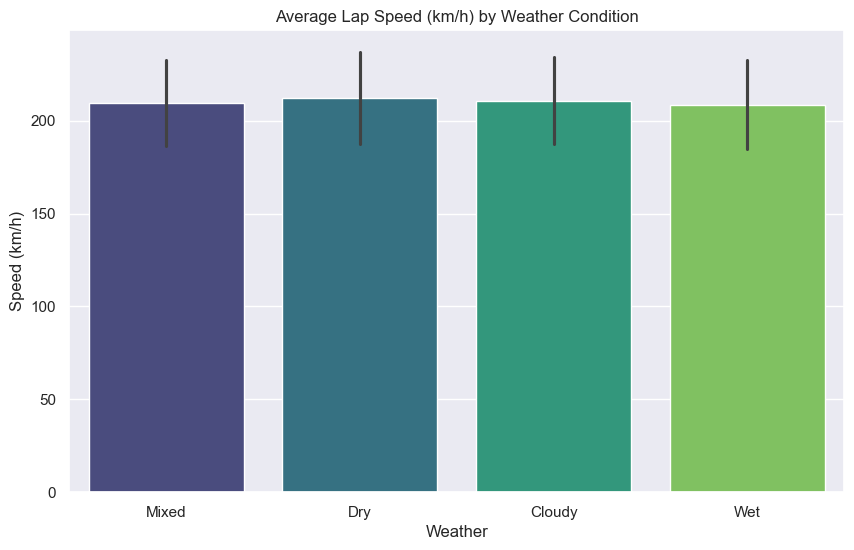

In [4]:
weather_speed = df.groupby('weather_condition')['avg_lap_speed_kmh'].agg(['mean', 'std', 'count']).reset_index()
print(weather_speed)

sns.barplot(data=df, x='weather_condition', y='avg_lap_speed_kmh', errorbar='sd', palette='viridis')
plt.title('Average Lap Speed (km/h) by Weather Condition')
plt.ylabel('Speed (km/h)')
plt.xlabel('Weather')
plt.show()

## 4. Weather vs. Safety Car Severity
Does wet or mixed weather trigger more full safety cars or red flags compared to dry weather?

safety_car_event     Full SC   Red Flag  Virtual SC
weather_condition                                  
Cloudy             32.352941  17.647059   50.000000
Dry                27.777778  20.833333   51.388889
Mixed              27.777778  27.777778   44.444444
Wet                53.846154   7.692308   38.461538


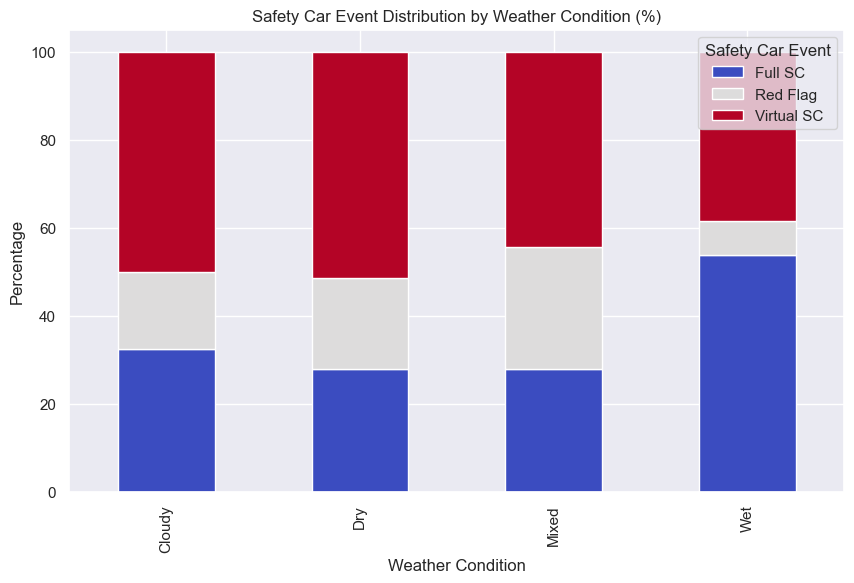

In [5]:
sc_weather = pd.crosstab(df['weather_condition'], df['safety_car_event'], normalize='index') * 100
print(sc_weather)

sc_weather.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Safety Car Event Distribution by Weather Condition (%)')
plt.ylabel('Percentage')
plt.xlabel('Weather Condition')
plt.legend(title='Safety Car Event')
plt.show()

## 5. Tyre Strategy vs. Average Speed
Here we analyze how combinations of starting and final tyre compounds affect average lap speed.

tyre_compound_final        Hard      Medium        Soft
tyre_compound_start                                    
Hard                 207.656471  212.138507  210.856027
Medium               206.571264  215.132471  206.718250
Soft                 212.320920  215.316027  212.644250


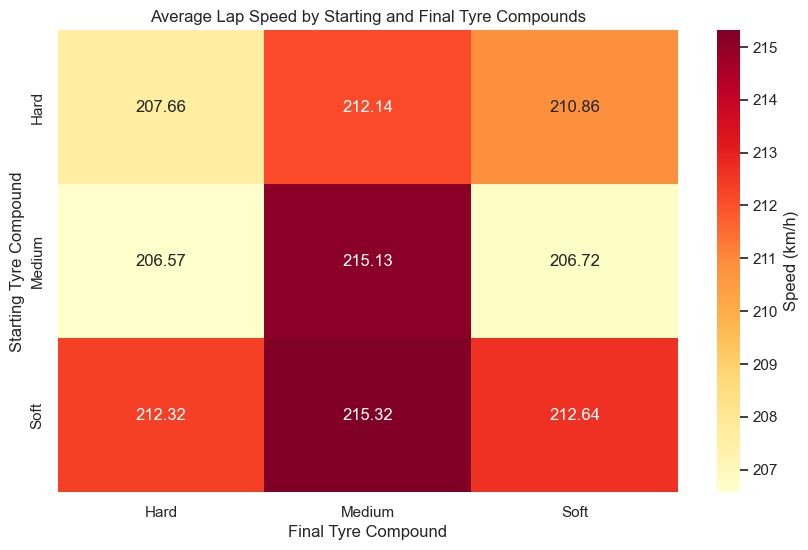

In [6]:
tyre_speed = df.groupby(['tyre_compound_start', 'tyre_compound_final'])['avg_lap_speed_kmh'].mean().unstack()
print(tyre_speed)

sns.heatmap(tyre_speed, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Speed (km/h)'})
plt.title('Average Lap Speed by Starting and Final Tyre Compounds')
plt.xlabel('Final Tyre Compound')
plt.ylabel('Starting Tyre Compound')
plt.show()

## 6. Pit Stops (Stints) vs. Points Scored
Let's see if taking more pit stops (resulting in more stints on fresher tyres) pays off in terms of scoring championship points.

   stint_count      mean  count
0            1  0.000000     28
1            2  3.513812    181
2            3  4.360656    183
3            4  4.241176    170
4            5  5.289855    138


C:\Users\hpvic\AppData\Local\Temp\ipykernel_12036\3061605408.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stint_count', y='points_scored', palette='Set2')


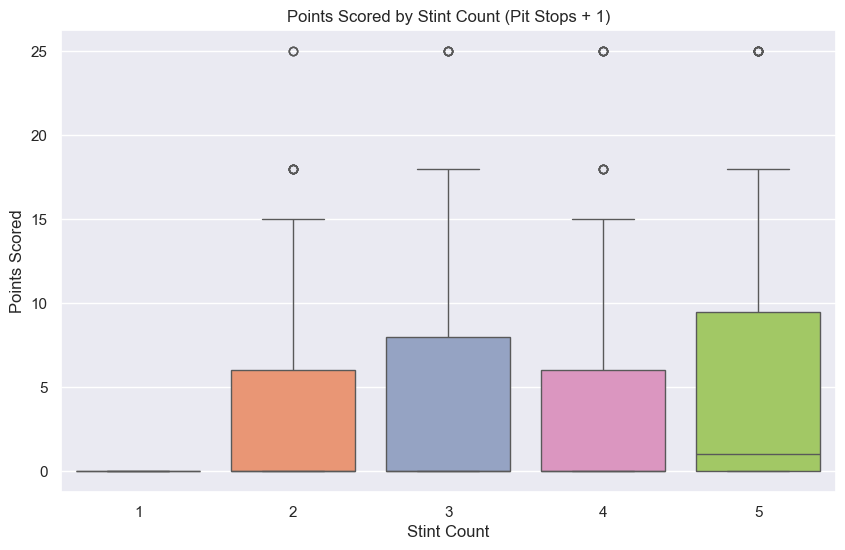

In [7]:
stint_points = df.groupby('stint_count')['points_scored'].agg(['mean', 'count']).reset_index()
print(stint_points)

sns.boxplot(data=df, x='stint_count', y='points_scored', palette='Set2')
plt.title('Points Scored by Stint Count (Pit Stops + 1)')
plt.xlabel('Stint Count')
plt.ylabel('Points Scored')
plt.show()

## 7. Numerical Correlations
We calculate the correlations among various numerical features of the sirkuit and results.

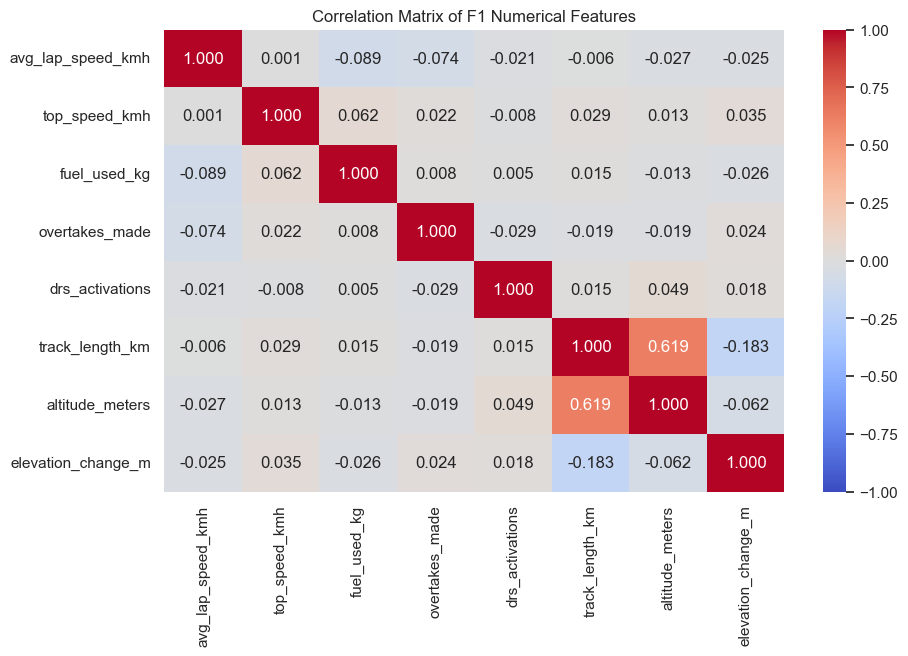

In [8]:
cols = ['avg_lap_speed_kmh', 'top_speed_kmh', 'fuel_used_kg', 'overtakes_made', 
        'drs_activations', 'track_length_km', 'altitude_meters', 'elevation_change_m']
corr = df[cols].corr()

sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Correlation Matrix of F1 Numerical Features')
plt.show()